In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("akash2907/bird-species-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bird-species-classification' dataset.
Path to dataset files: /kaggle/input/bird-species-classification


In [6]:
! cp -r /kaggle/input/bird-species-classification /content/dataset

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers , models
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import numpy as np

# Data Preprocesing

## Splitting

In [7]:
train_path = "/content/dataset/train_data/train_data"
test_path = "/content/dataset/test_data/test_data"

In [8]:
imgage_size = (224 , 224)
batch_size = 16
seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.17,
    subset="training",
    image_size=imgage_size,
    batch_size=batch_size,
    seed = seed
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.17,
    subset="validation",
    image_size=imgage_size,
    batch_size=batch_size,
    seed = seed
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=imgage_size,
    batch_size=batch_size,
    seed = seed
)

Found 150 files belonging to 16 classes.
Using 125 files for training.
Found 150 files belonging to 16 classes.
Using 25 files for validation.
Found 157 files belonging to 16 classes.


In [9]:
class_names = train_ds.class_names

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 16
['blasti', 'bonegl', 'brhkyt', 'cbrtsh', 'cmnmyn', 'gretit', 'hilpig', 'himbul', 'himgri', 'hsparo', 'indvul', 'jglowl', 'lbicrw', 'mgprob', 'rebimg', 'wcrsrt']


## Aututone

In [10]:
AutoTune = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AutoTune)
validation_ds = validation_ds.cache().prefetch(buffer_size=AutoTune)
test_ds = test_ds.cache().prefetch(buffer_size=AutoTune)

## Showing A Sample

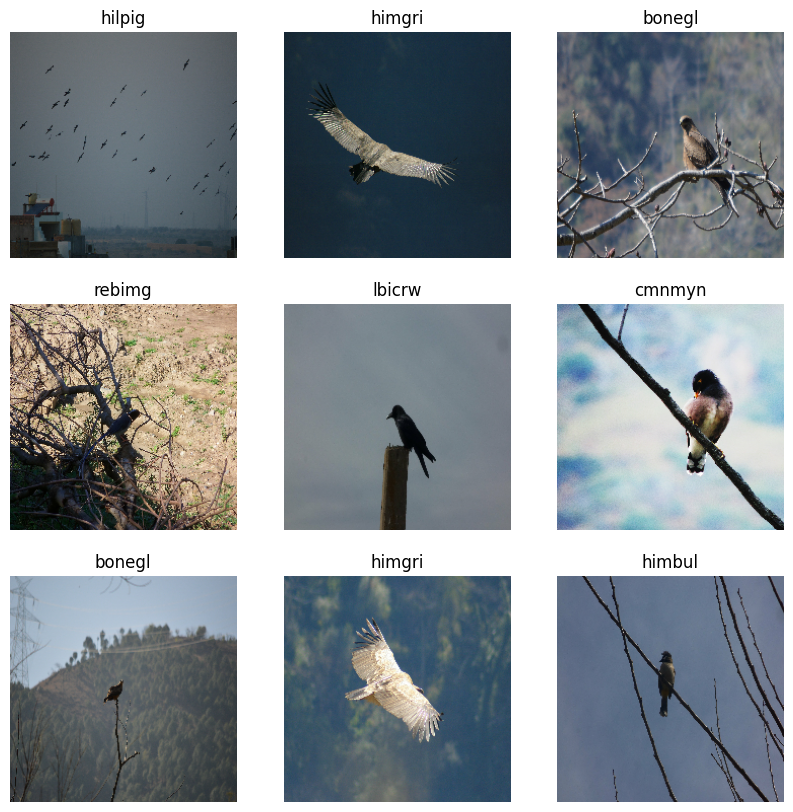

In [11]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

## Augmentation

In [54]:
Augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1),
])

# Baseline CNN

In [13]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    Augmentation,
    layers.Rescaling(1./255),
    
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same',use_bias=False),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
        
    layers.GlobalAveragePooling2D(),
        
    layers.BatchNormalization(),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.6),
    
    layers.Dense(len(class_names), activation='softmax')
    
])

In [14]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 3)    │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,804 (7.05 KB)

 Trainable params: 1,734 (6.77 KB)

 Non-trainable params: 70 (280.00 B)

In [28]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(train_ds, validation_data=validation_ds, epochs=40, callbacks=[early_stopping], verbose=1)

Epoch 1/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2720 - loss: 2.2011 - val_accuracy: 0.3200 - val_loss: 2.2553
Epoch 2/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2720 - loss: 2.2535 - val_accuracy: 0.3200 - val_loss: 2.2677
Epoch 3/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3040 - loss: 2.2987 - val_accuracy: 0.2800 - val_loss: 2.3128
Epoch 4/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2800 - loss: 2.0719 - val_accuracy: 0.2800 - val_loss: 2.3312
Epoch 5/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2560 - loss: 2.2108 - val_accuracy: 0.3200 - val_loss: 2.3009
Epoch 6/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3520 - loss: 2.1110 - val_accuracy: 0.3200 - val_loss: 2.2385
Epoch 7/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3120 - loss: 2.1155 - val_accuracy: 0.3200 - val_loss: 2.2293
Epoch 8/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3120 - loss: 2.1061 - val_accuracy: 0.3200 - val_loss: 2.2357


In [29]:
loss , acc = model.evaluate(test_ds)
print("Accuracy: ", acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2866 - loss: 2.3482 
Accuracy:  0.2866241931915283


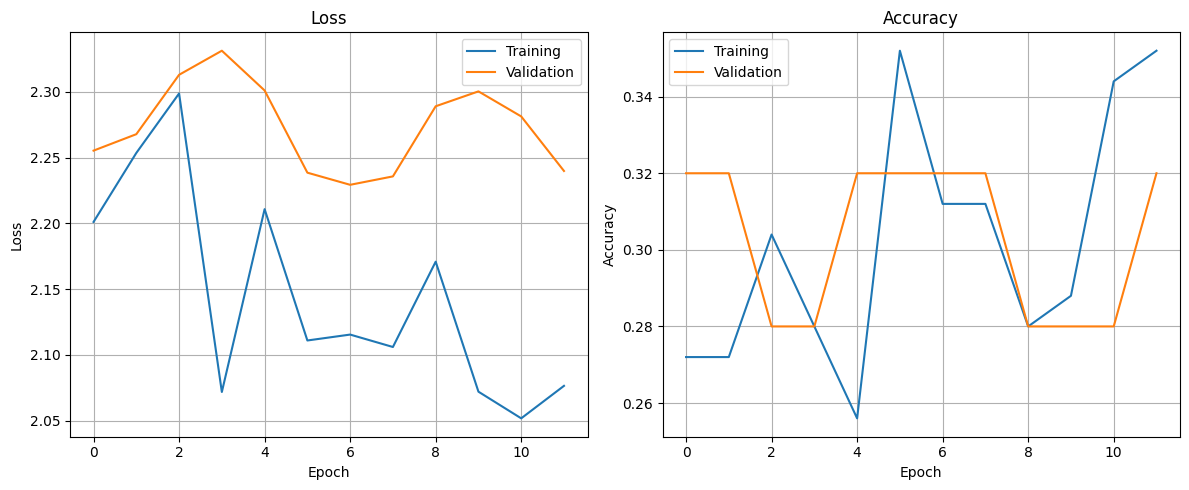

In [30]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Using EfficientNetB0

In [31]:
from tensorflow.keras.applications import EfficientNetB0

## Transfer Learning

In [32]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

base_model.trainable = False

model_efficient = models.Sequential([
    layers.Input(shape=(224,224,3)),
    
    Augmentation,
    base_model,
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    
    layers.Dense(len(class_names), activation='softmax')
])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [35]:
model_efficient.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_efficient.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,215,603 (16.08 MB)

 Trainable params: 166,032 (648.56 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [45]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_efficient = model_efficient.fit(train_ds, validation_data=validation_ds, epochs=40, callbacks=[early_stopping], verbose=1)

Epoch 1/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.9600 - loss: 0.1129 - val_accuracy: 0.7600 - val_loss: 0.8656
Epoch 2/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.9920 - loss: 0.1030 - val_accuracy: 0.8000 - val_loss: 0.8543
Epoch 3/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9760 - loss: 0.1113 - val_accuracy: 0.8000 - val_loss: 0.8560
Epoch 4/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 1.0000 - loss: 0.0767 - val_accuracy: 0.8000 - val_loss: 0.8260
Epoch 5/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9920 - loss: 0.0859 - val_accuracy: 0.8000 - val_loss: 0.7952
Epoch 6/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.9920 - loss: 0.0715 - val_accuracy: 0.8000 - val_loss: 0.8487
Epoch 7/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9760 - loss: 0.0926 - val_accuracy: 0.8000 - val_loss: 0.9153
Epoch 8/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9840 - loss: 0.0722 - val_accuracy: 0.8000 - val_loss: 0.9473


In [46]:
loss, acc = model_efficient.evaluate(test_ds)

print("Accuracy:", acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4968 - loss: 2.1243
Accuracy: 0.4968152940273285


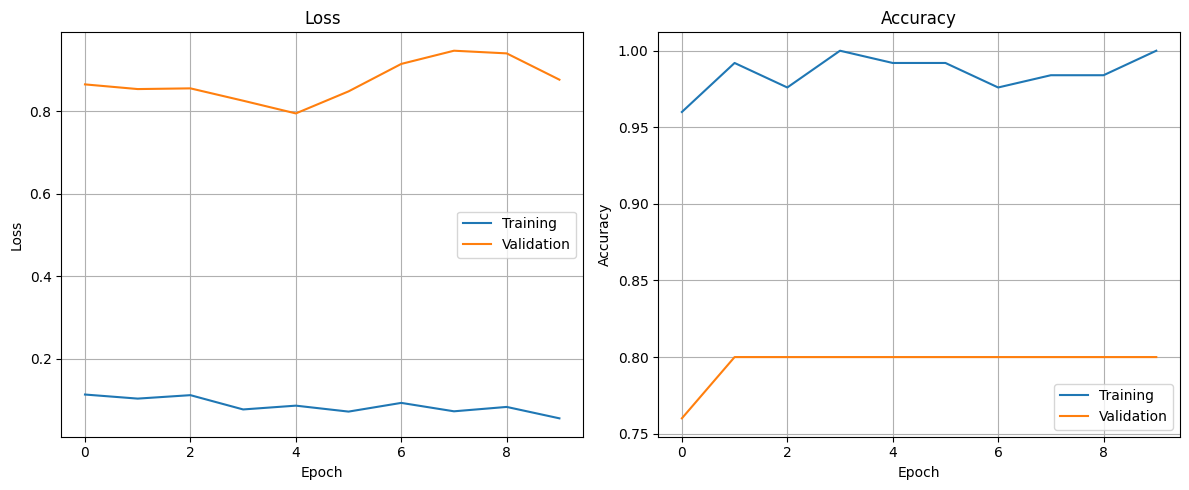

In [53]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_efficient.history['loss'], label='Training')
plt.plot(history_efficient.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(history_efficient.history['accuracy'], label='Training')
plt.plot(history_efficient.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Fine Tuning

In [47]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

In [ ]:
model_efficient.compile(optimizer=tf.keras.optimizers.Adam(1e-5),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [50]:
history_efficient_finetune = model_efficient.fit(train_ds,validation_data=validation_ds,epochs=40,callbacks=[early_stopping])

Epoch 1/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9280 - loss: 0.5614 - val_accuracy: 0.8000 - val_loss: 0.7851
Epoch 2/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9120 - loss: 0.5220 - val_accuracy: 0.8000 - val_loss: 0.7848
Epoch 3/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9120 - loss: 0.5496 - val_accuracy: 0.8000 - val_loss: 0.7896
Epoch 4/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.9120 - loss: 0.5539 - val_accuracy: 0.8000 - val_loss: 0.7969
Epoch 5/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9440 - loss: 0.4859 - val_accuracy: 0.8000 - val_loss: 0.8080
Epoch 6/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9280 - loss: 0.4521 - val_accuracy: 0.7600 - val_loss: 0.8186
Epoch 7/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9200 - loss: 0.4607 - val_accuracy: 0.7600 - val_loss: 0.8287


In [51]:
loss, acc = model_efficient.evaluate(test_ds)

print("Accuracy:", acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4904 - loss: 2.0008
Accuracy: 0.4904458522796631
